In [5]:
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [6]:
# Initialize the FRED API with your key
fred = Fred(api_key='28b45a1ad0d00a5c990384991a17355c') # Replace my APIKEY with "YOUR_API_KEY"

# List of Treasury yield series IDs
series_ids = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', \
              'DGS7', 'DGS10', 'DGS20', 'DGS30']

# Function to get data for a single series
def get_yield_data(series_id):
    data = fred.get_series(series_id, observation_start="1975-01-01", observation_end="2024-05-03")
    return data

# Get data for all series
yields_dict = {series_id: get_yield_data(series_id) for series_id in series_ids}

# Combine into a single DataFrame
yields = pd.DataFrame(yields_dict)

# Rename columns for clarity
yields.columns = ['1 Month', '3 Month', '6 Month', '1 Year', '2 Year', '3 Year', '5 Year', \
                  '7 Year', '10 Year', '20 Year', '30 Year']

In [7]:
yields.index = pd.to_datetime(yields.index)
yields.loc['2020-01-03']

1 Month    1.52
3 Month    1.52
6 Month    1.55
1 Year     1.55
2 Year     1.53
3 Year     1.54
5 Year     1.59
7 Year     1.71
10 Year    1.80
20 Year    2.11
30 Year    2.26
Name: 2020-01-03 00:00:00, dtype: float64

In [13]:
yields

,1 Month,3 Month,6 Month,1 Year,2 Year,3 Year,5 Year,7 Year,10 Year,20 Year,30 Year
1975-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-01-02,NaN,NaN,NaN,7.27,NaN,7.34,7.34,7.34,7.42,7.94,NaN
1975-01-03,NaN,NaN,NaN,7.19,NaN,7.33,7.36,7.36,7.43,7.92,NaN
1975-01-06,NaN,NaN,NaN,7.10,NaN,7.29,7.34,7.33,7.39,7.89,NaN
1975-01-07,NaN,NaN,NaN,7.00,NaN,7.26,7.35,7.34,7.38,7.89,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2024-04-29,5.48,5.45,5.43,5.20,4.97,4.80,4.65,4.64,4.63,4.86,4.75
2024-04-30,5.48,5.46,5.44,5.25,5.04,4.87,4.72,4.71,4.69,4.90,4.79
2024-05-01,5.47,5.46,5.43,5.21,4.96,4.79,4.64,4.64,4.63,4.85,4.74
2024-05-02,5.51,5.46,5.42,5.16,4.87,4.71,4.57,4.57,4.58,4.82,4.72


In [12]:
yields.isna().sum(axis = 0)

1 Month    7180
3 Month    2204
6 Month    2204
1 Year      542
2 Year      894
3 Year      542
5 Year      542
7 Year      542
10 Year     542
20 Year    2231
30 Year    1072
dtype: int64

In [7]:
# We can see that during the days that the 10-year is not reported,
# none maturity is reported as well.
yields[yields['10 Year'].isna() == True].sum(axis = 0)

1 Month    0.0
3 Month    0.0
6 Month    0.0
1 Year     0.0
2 Year     0.0
3 Year     0.0
5 Year     0.0
7 Year     0.0
10 Year    0.0
20 Year    0.0
30 Year    0.0
dtype: float64

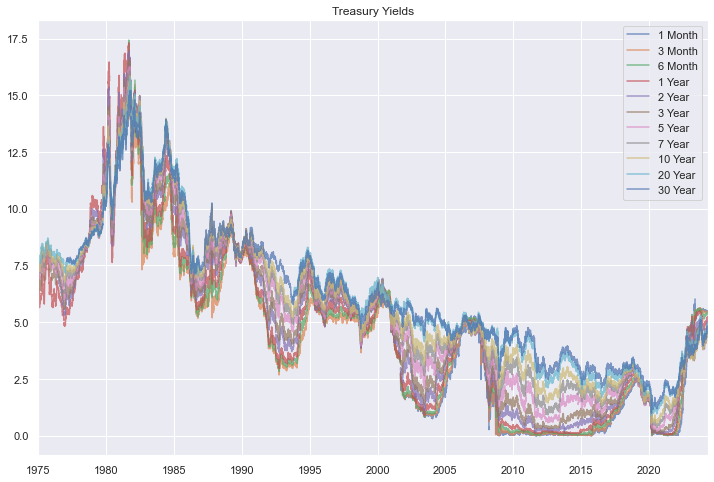

In [8]:
# Figure 1
yields.plot(figsize=(12, 8), title='Treasury Yields', alpha=0.7) # Plot the yields
plt.show()

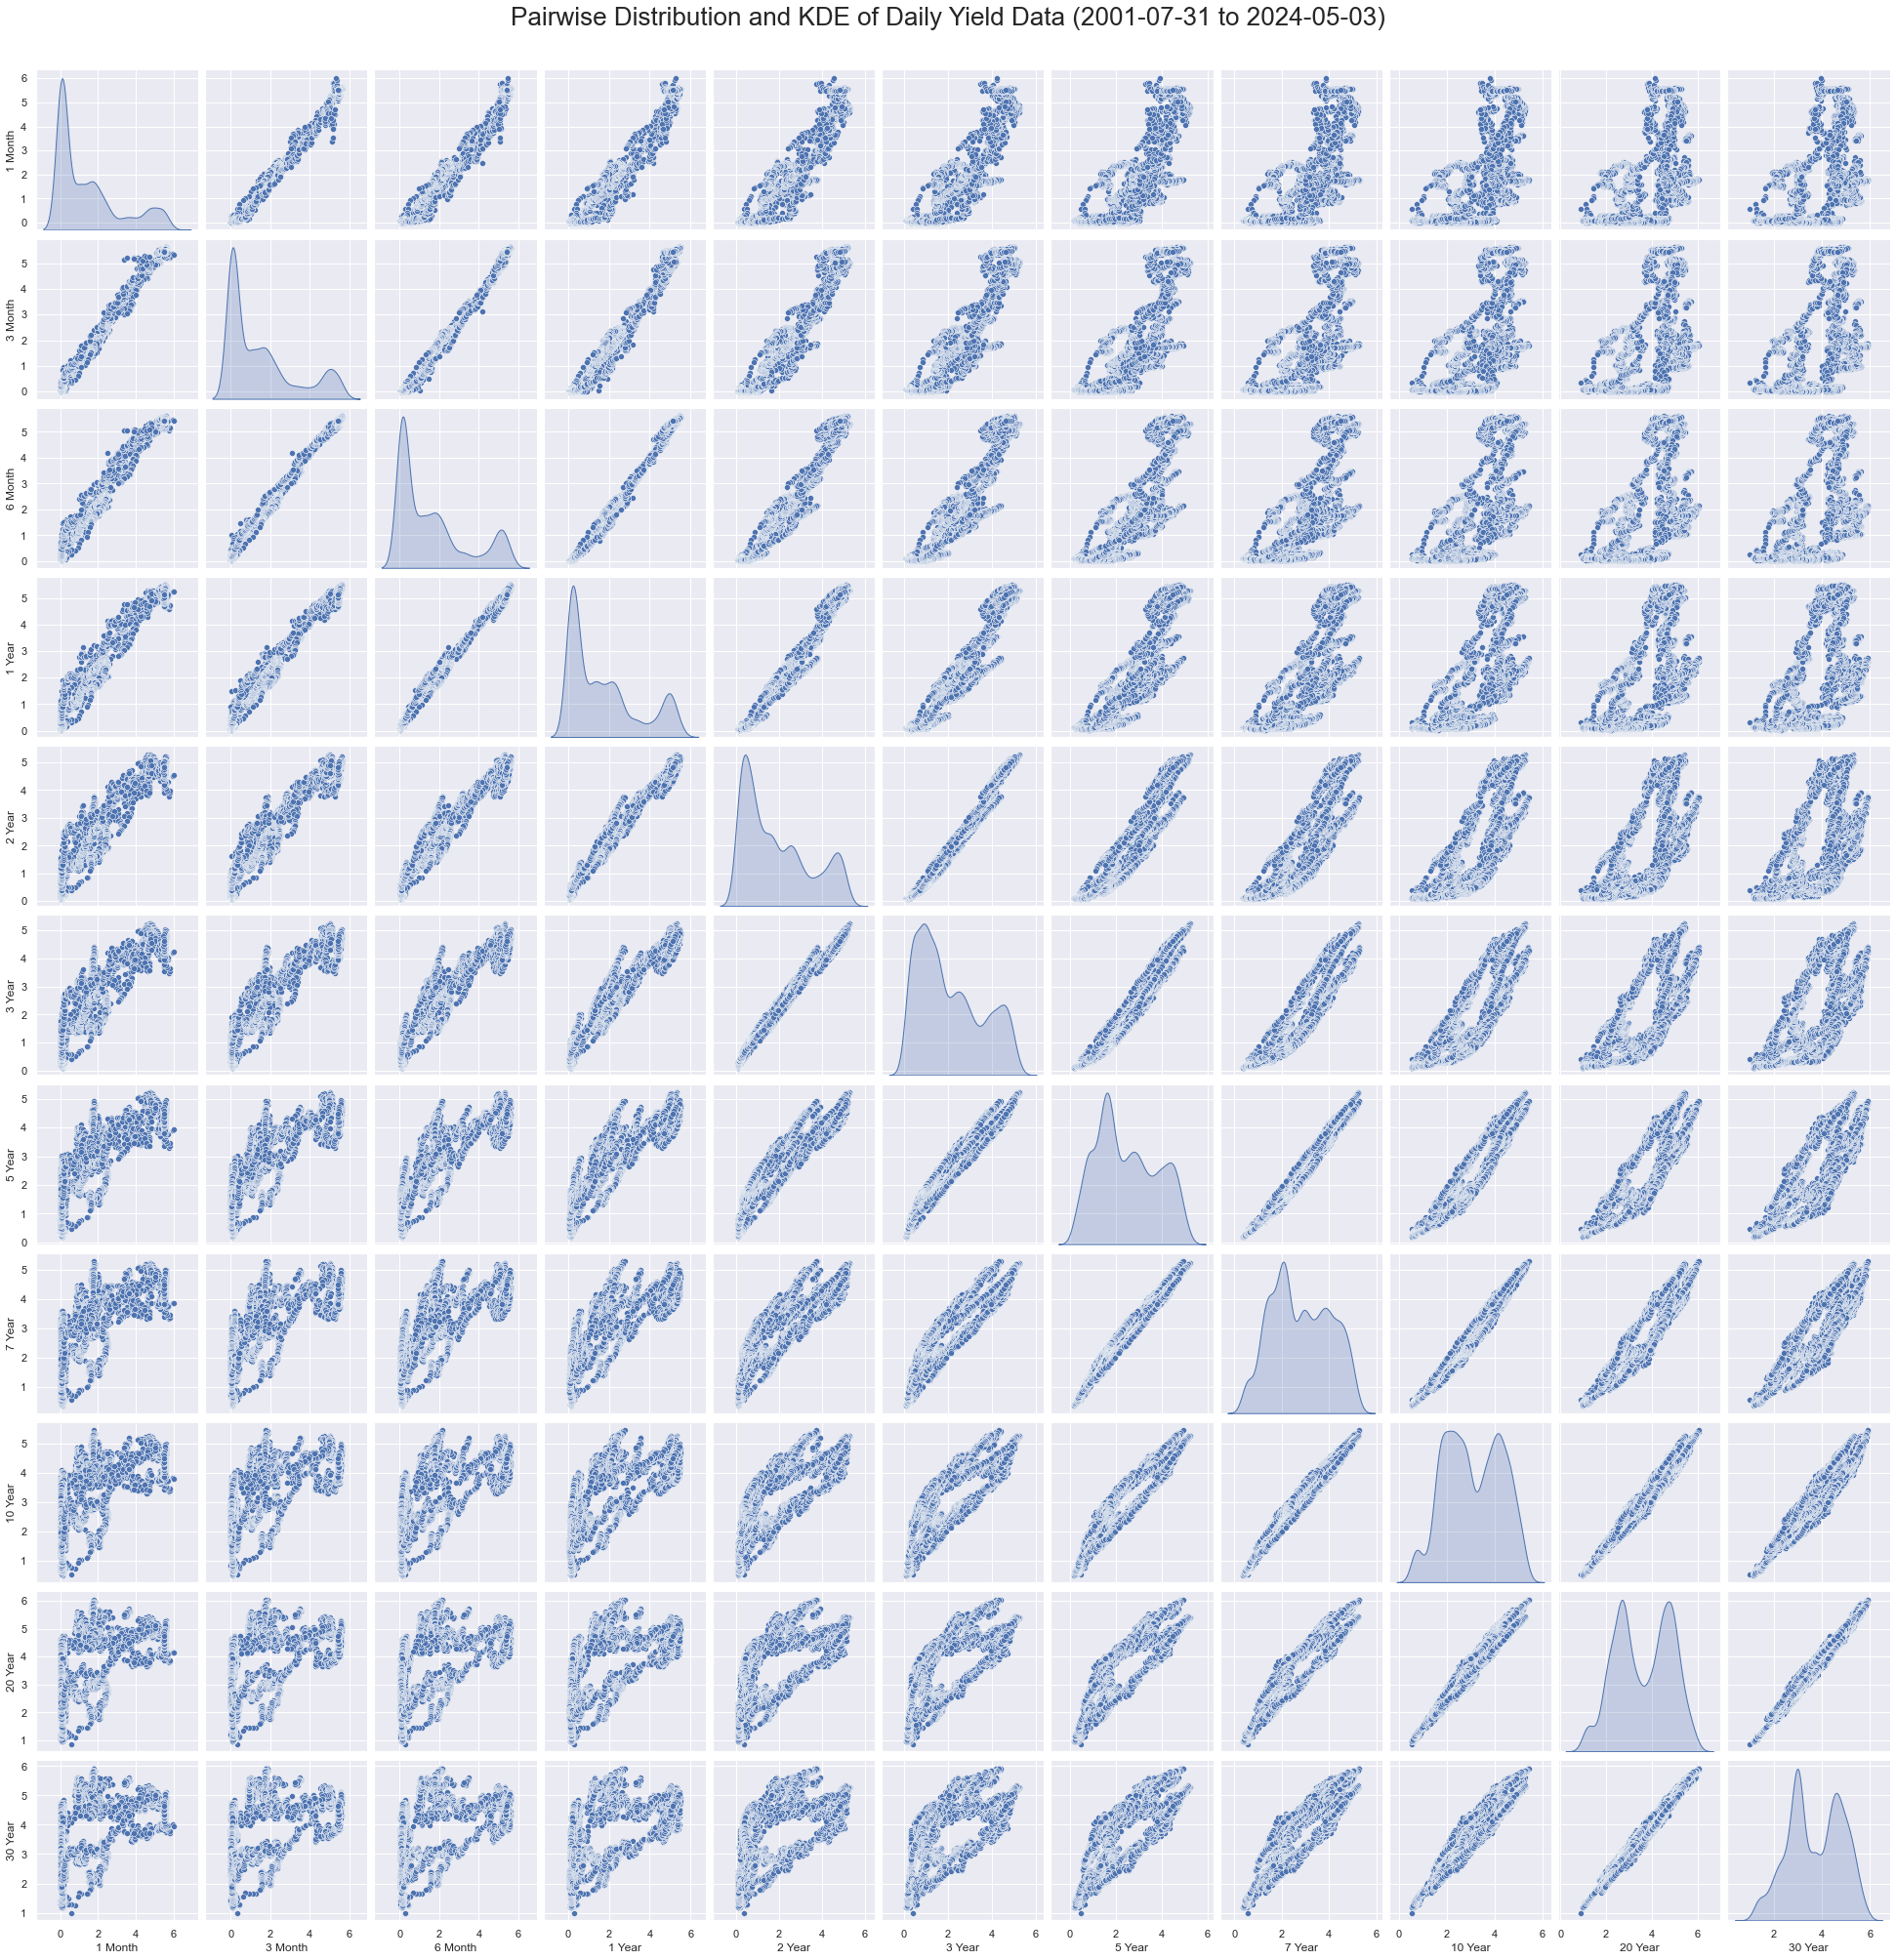

In [9]:
# Figure 2
sns.pairplot(yields.dropna(), diag_kind='kde') # Pairplot with KDE on the diagonal
plt.suptitle("Pairwise Distribution and KDE of Daily Yield Data (2001-07-31 to 2024-05-03)",
             y=1.02, fontsize=26)
plt.show()

C:\Users\pc\AppData\Local\Temp/ipykernel_40524/2521112310.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])


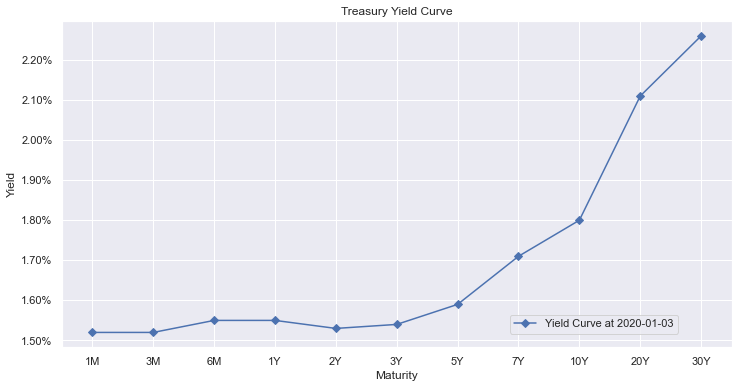

In [14]:
# Figure 3

def plot_yield_curve(date):
    maturities = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y'] # Maturities
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(maturities, yields.loc[date], marker='D', label='Yield Curve at ' + date)

    ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])
    ax.set_xticks(range(len(maturities)))
    ax.set_xticklabels(maturities)

    # Add labels and title
    ax.set_xlabel('Maturity')
    ax.set_ylabel('Yield')
    ax.set_title('Treasury Yield Curve')

    fig.legend(loc = [0.69, 0.14])

    # Show the plot
    plt.grid(True)
    plt.show()

plot_yield_curve('2020-01-03')

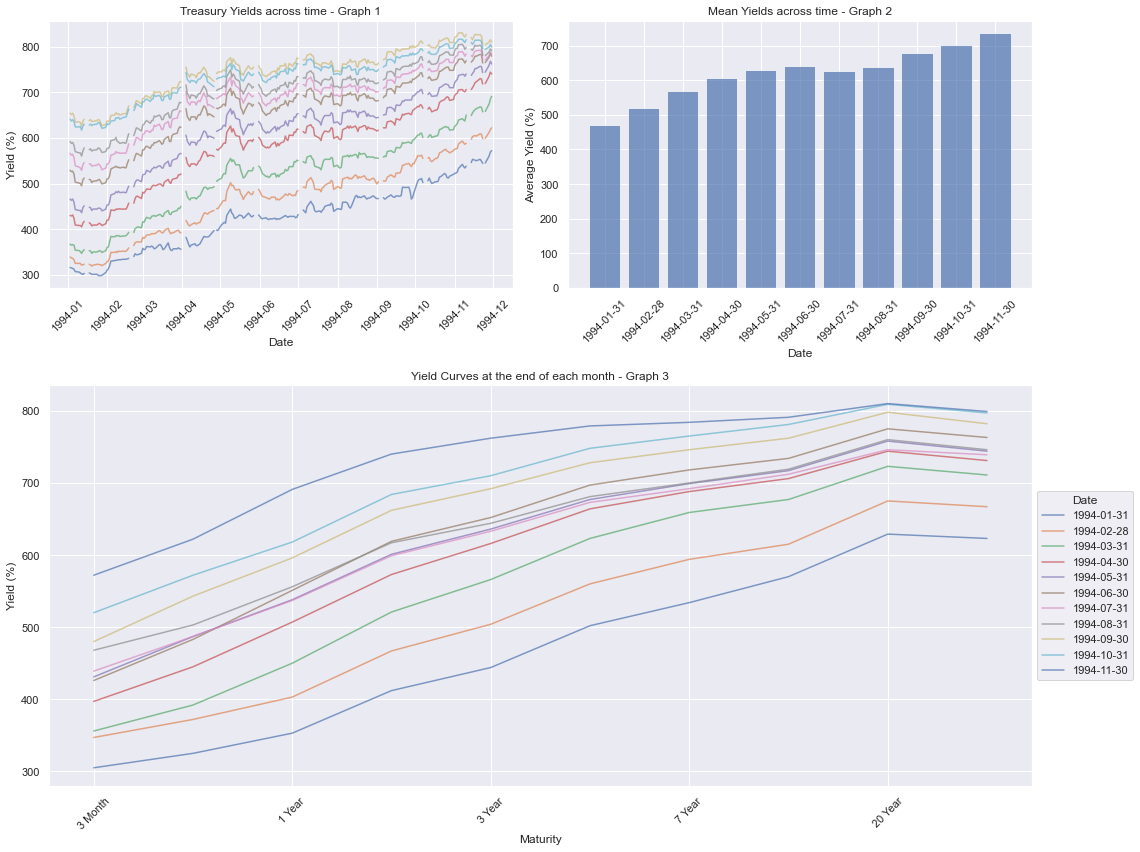

In [15]:
# Figure 4

from matplotlib.gridspec import GridSpec

# Preparing the data
bond_market_crash = yields.loc['1994-01-03': '1994-11-30'].iloc[:,1:] * 100  # Convert yields to percentage
resampled_monthly_bond_market_crash = bond_market_crash.resample('M').last()
resampled_monthly_bond_market_crash_ticks = resampled_monthly_bond_market_crash.index.strftime('%Y-%m-%d')

# Creating the plt object
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 2, height_ratios=[1, 1.5])

# First row, first column
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(bond_market_crash, alpha=0.7)
ax1.set_title('Treasury Yields across time - Graph 1')
ax1.set_xlabel('Date')
ax1.set_ylabel('Yield (%)')
ax1.tick_params(axis='x', rotation=45)

# First row, second column
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(resampled_monthly_bond_market_crash_ticks, resampled_monthly_bond_market_crash.mean(axis=1), alpha=0.7)
ax2.set_title('Mean Yields across time - Graph 2')
ax2.set_xlabel('Date')
ax2.set_ylabel('Average Yield (%)')
ax2.tick_params(axis='x', rotation=45)

# Second row
ax3 = fig.add_subplot(gs[1, :])
for i in range(len(resampled_monthly_bond_market_crash)):
    date = resampled_monthly_bond_market_crash_ticks[i]
    resampled_monthly_bond_market_crash.iloc[i, :].plot(ax=ax3, alpha=0.7, label=date)

ax3.set_title('Yield Curves at the end of each month - Graph 3')
ax3.set_xlabel('Maturity')
ax3.set_ylabel('Yield (%)')
ax3.legend(title='Date', loc='center left', bbox_to_anchor=(1, 0.5))
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

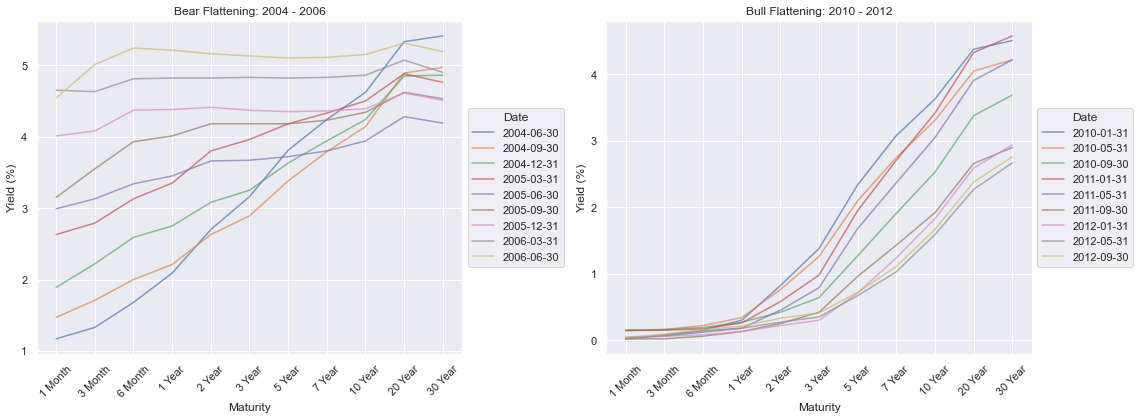

In [16]:
# Figure 5

# Preparing the data
bear_flattening = yields['2004-06-01':'2006-06-30'].resample('3M').last()
bear_flattening.index = bear_flattening.index.strftime('%Y-%m-%d')

bull_flattening = yields['2010-01-01':'2012-06-30'].resample('4M').last()
bull_flattening.index = bull_flattening.index.strftime('%Y-%m-%d')

# Creating the plt object
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bear flattening graph
for i in range(len(bear_flattening)):
    date = bear_flattening.index[i]
    ax1.plot(bear_flattening.columns, bear_flattening.iloc[i, :], alpha=0.7, label=date)
ax1.set_title('Bear Flattening: 2004 - 2006')
ax1.set_xlabel('Maturity')
ax1.set_ylabel('Yield (%)')
ax1.legend(title='Date', loc='center left', bbox_to_anchor=(1, 0.5))
ax1.tick_params(axis='x', rotation=45)

# Bull flattening graph
for i in range(len(bull_flattening)):
    date = bull_flattening.index[i]
    ax2.plot(bull_flattening.columns, bull_flattening.iloc[i, :], alpha=0.7, label=date)
ax2.set_title('Bull Flattening: 2010 - 2012')
ax2.set_xlabel('Maturity')
ax2.set_ylabel('Yield (%)')
ax2.legend(title='Date', loc='center left', bbox_to_anchor=(1, 0.5))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
